In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1949_bacteria_4880.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/per

In [1]:
# ====================================================
# 0. Setup & Imports
# ====================================================

import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)

from skimage.feature import hog

# Try importing timm for Vision Transformers
try:
    import timm
    HAS_TIMM = True
except ImportError:
    print("timm is not installed. Install it with `pip install timm` to run ViT experiments.")
    HAS_TIMM = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Metal (mps) device")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA GPU")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

DEVICE



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using CUDA GPU


device(type='cuda')

In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Input, Dense,GlobalAveragePooling2D,BatchNormalization

In [43]:
def read_data(data_dir):
    img_paths=[]
    labels=[]
    
    for folder in os.listdir(data_dir):
        folder_path=os.path.join(data_dir,folder)
        for img_path in os.listdir(folder_path):
            imgpath=os.path.join(folder_path,img_path)
            img_paths.append(imgpath)
            labels.append(folder)
    df=pd.DataFrame({'img_path':img_paths,'labels':labels}) 
    
    return df   

train_data=read_data("/kaggle/input/chest-xray-pneumonia/chest_xray/train/")
test_data=read_data("/kaggle/input/chest-xray-pneumonia/chest_xray/test/")
valid_data=read_data("/kaggle/input/chest-xray-pneumonia/chest_xray/val/")


In [46]:
print("Train:", len(train_data))
print("Val:", len(test_data))
print("Test:", len(valid_data))


def show_split_proportions_df(df, split_name):
    total = len(df)
    print(f"\n{split_name} split: {total} images")

    counts = df['labels'].value_counts()

    for label, count in counts.items():
        print(f"  {label}: {count} ({count/total:.2%})")

show_split_proportions_df(train_data, "Train")
show_split_proportions_df(valid_data, "Val")
show_split_proportions_df(test_data,  "Test")


Train: 5216
Val: 624
Test: 16

Train split: 5216 images
  PNEUMONIA: 3875 (74.29%)
  NORMAL: 1341 (25.71%)

Val split: 16 images
  PNEUMONIA: 8 (50.00%)
  NORMAL: 8 (50.00%)

Test split: 624 images
  PNEUMONIA: 390 (62.50%)
  NORMAL: 234 (37.50%)


merging

In [47]:
import pandas as pd

all_data = pd.concat([train_data, valid_data, test_data], ignore_index=True)

print("Total images after merge:", len(all_data))
print(all_data["labels"].value_counts())


Total images after merge: 5856
labels
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


In [48]:
# Separate by class
normal_df = all_data[all_data["labels"] == "NORMAL"]
pneu_df   = all_data[all_data["labels"] == "PNEUMONIA"]

n_normal = len(normal_df)
n_pneu   = len(pneu_df)

print("NORMAL:", n_normal, "  PNEUMONIA:", n_pneu)

# Undersample PNEUMONIA to match NORMAL
pneu_df_down = pneu_df.sample(n=n_normal, random_state=42)

# Combine and shuffle
balanced_df = pd.concat([normal_df, pneu_df_down], ignore_index=True)
balanced_df = balanced_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(balanced_df["labels"].value_counts())


NORMAL: 1583   PNEUMONIA: 4273

After balancing:
labels
NORMAL       1583
PNEUMONIA    1583
Name: count, dtype: int64


In [49]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp (val + test)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    stratify=balanced_df["labels"],
    random_state=42
)

# Split temp into 15% val, 15% test (i.e. 50/50 of the 30%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["labels"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

print("\nTrain label ratio:")
print(train_df["labels"].value_counts(normalize=True))

print("\nVal label ratio:")
print(val_df["labels"].value_counts(normalize=True))

print("\nTest label ratio:")
print(test_df["labels"].value_counts(normalize=True))


Train: 2216
Val:   475
Test:  475

Train label ratio:
labels
PNEUMONIA    0.5
NORMAL       0.5
Name: proportion, dtype: float64

Val label ratio:
labels
PNEUMONIA    0.501053
NORMAL       0.498947
Name: proportion, dtype: float64

Test label ratio:
labels
NORMAL       0.501053
PNEUMONIA    0.498947
Name: proportion, dtype: float64


In [50]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

label_map = {"NORMAL": 0, "PNEUMONIA": 1}

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.labels = self.df["labels"].map(label_map).values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]
        label = self.labels[idx]

        img = Image.open(img_path).convert("L")

        if self.transform is not None:
            img = self.transform(img)

        return img, label


In [51]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 4

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset   = ChestXrayDataset(val_df,   transform=test_transform)
test_dataset  = ChestXrayDataset(test_df,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


In [53]:
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2216
Val: 475
Test: 475


In [59]:
import torch

def check_loader_classes(loader, split_name, class_names):
    counts = torch.zeros(len(class_names), dtype=torch.long)

    for images, labels in loader:
        # labels are numeric (0/1)
        batch_counts = torch.bincount(labels, minlength=len(class_names))
        counts += batch_counts

    total = counts.sum().item()
    print(f"\n{split_name} Loader: {total} samples")

    for i, cls in enumerate(class_names):
        count = counts[i].item()
        print(f"  {cls}: {count} ({count/total:.2%})")
class_names = ["NORMAL", "PNEUMONIA"]

check_loader_classes(train_loader, "Train", class_names)
check_loader_classes(val_loader,   "Val",   class_names)
check_loader_classes(test_loader,  "Test",  class_names)



Train Loader: 2216 samples
  NORMAL: 1108 (50.00%)
  PNEUMONIA: 1108 (50.00%)

Val Loader: 475 samples
  NORMAL: 237 (49.89%)
  PNEUMONIA: 238 (50.11%)

Test Loader: 475 samples
  NORMAL: 238 (50.11%)
  PNEUMONIA: 237 (49.89%)


In [57]:
train_df

,img_path,labels
367,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
91,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1073,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
2666,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1926,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
...,...,...
2263,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2008,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3121,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
1392,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


In [67]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.append(labels.numpy())
        all_preds.append(preds.cpu().numpy())

    return np.concatenate(all_labels), np.concatenate(all_preds)


In [68]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2, activation="relu", dropout_p=0.5):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU
        elif activation == "leaky_relu":
            act = lambda: nn.LeakyReLU(0.1)
        elif activation == "elu":
            act = nn.ELU
        else:
            raise ValueError("Invalid activation")

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), act(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), act(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), act(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), act(), nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            act(),
            nn.Dropout(dropout_p),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [76]:
cnn = SimpleCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-4, weight_decay=1e-4)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

epochs = 10
for epoch in range(1, epochs+1):
    train_loss, train_acc = train_one_epoch(cnn, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(cnn, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{epochs} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10 | Train Acc: 0.8344 | Val Acc: 0.9305
Epoch 2/10 | Train Acc: 0.9206 | Val Acc: 0.9516
Epoch 3/10 | Train Acc: 0.9255 | Val Acc: 0.9684
Epoch 4/10 | Train Acc: 0.9328 | Val Acc: 0.9600
Epoch 5/10 | Train Acc: 0.9395 | Val Acc: 0.9579
Epoch 6/10 | Train Acc: 0.9287 | Val Acc: 0.9579
Epoch 7/10 | Train Acc: 0.9400 | Val Acc: 0.9684
Epoch 8/10 | Train Acc: 0.9458 | Val Acc: 0.9705
Epoch 9/10 | Train Acc: 0.9395 | Val Acc: 0.9558
Epoch 10/10 | Train Acc: 0.9499 | Val Acc: 0.9726


In [77]:
test_loss, test_acc = evaluate(cnn, test_loader, criterion)
y_true, y_pred = get_predictions(cnn, test_loader)

print("CNN Test Accuracy:", test_acc)
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))
print(confusion_matrix(y_true, y_pred))


CNN Test Accuracy: 0.9347368421052632
              precision    recall  f1-score   support

      NORMAL       0.95      0.92      0.93       238
   PNEUMONIA       0.92      0.95      0.94       237

    accuracy                           0.93       475
   macro avg       0.94      0.93      0.93       475
weighted avg       0.94      0.93      0.93       475

[[219  19]
 [ 12 225]]


In [78]:
import matplotlib.pyplot as plt

def plot_cnn_training(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # ----------------------- LOSS -----------------------
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN Loss Curve")
    plt.legend()

    # ----------------------- ACCURACY -----------------------
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("CNN Accuracy Curve")
    plt.legend()

    plt.suptitle("CNN Training Curves")
    plt.tight_layout()
    plt.show()


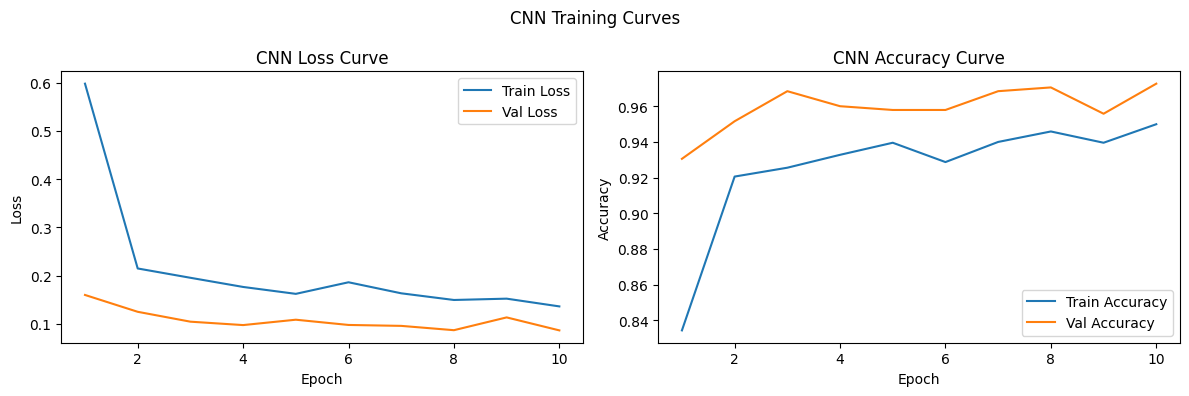

In [80]:
plot_cnn_training(history)


In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["NORMAL", "PNEUMONIA"]

def plot_confusion_matrix(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{model_name} Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     horizontalalignment="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


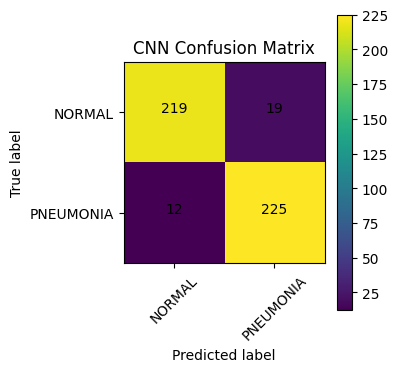

In [82]:
plot_confusion_matrix(y_true, y_pred, model_name="CNN")

In [83]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, cnn):
        super().__init__()
        self.features = cnn.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

feature_extractor = CNNFeatureExtractor(cnn).to(DEVICE)
feature_extractor.eval()


CNNFeatureExtractor(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_s

In [85]:
@torch.no_grad()
def extract_features(loader, model):
    all_feats = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE)
        feats = model(images)            # (B, D)
        all_feats.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

    X = np.concatenate(all_feats, axis=0)
    y = np.concatenate(all_labels, axis=0)
    return X, y


In [86]:
X_train, y_train = extract_features(train_loader, feature_extractor)
X_val, y_val = extract_features(val_loader, feature_extractor)
X_test, y_test = extract_features(test_loader, feature_extractor)


In [87]:
print("Train features:", X_train.shape)
print("Val features:", X_val.shape)
print("Test features:", X_test.shape)


Train features: (2216, 256)
Val features: (475, 256)
Test features: (475, 256)


In [88]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Test Accuracy:", acc_svm)
print(classification_report(y_test, y_pred_svm, target_names=["NORMAL", "PNEUMONIA"]))
print(confusion_matrix(y_test, y_pred_svm))


SVM Test Accuracy: 0.8947368421052632
              precision    recall  f1-score   support

      NORMAL       0.92      0.87      0.89       238
   PNEUMONIA       0.87      0.92      0.90       237

    accuracy                           0.89       475
   macro avg       0.90      0.89      0.89       475
weighted avg       0.90      0.89      0.89       475

[[206  32]
 [ 18 219]]


In [89]:
class ChestXrayDatasetRGB(ChestXrayDataset):
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]
        label = self.labels[idx]

        img = Image.open(img_path)  # leave as original, convert later
        if self.transform:
            img = self.transform(img)
        return img, label


In [90]:
vit_transform = T.Compose([
    T.Resize((224, 224)),
    T.Lambda(lambda img: img.convert("RGB")),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

train_vit = ChestXrayDatasetRGB(train_df, transform=vit_transform)
val_vit   = ChestXrayDatasetRGB(val_df, transform=vit_transform)
test_vit  = ChestXrayDatasetRGB(test_df, transform=vit_transform)

train_loader_vit = DataLoader(train_vit, batch_size=BATCH_SIZE, shuffle=True)
val_loader_vit   = DataLoader(val_vit, batch_size=BATCH_SIZE)
test_loader_vit  = DataLoader(test_vit, batch_size=BATCH_SIZE)


In [91]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT
vit = vit_b_16(weights=weights)

in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, 2)

vit = vit.to(DEVICE)

optimizer_vit = optim.Adam(vit.parameters(), lr=1e-4, weight_decay=1e-4)
criterion_vit = nn.CrossEntropyLoss()


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 190MB/s]  


In [92]:
epochs_vit = 5
for epoch in range(1, epochs_vit+1):
    tr_loss, tr_acc = train_one_epoch(vit, train_loader_vit, criterion_vit, optimizer_vit)
    val_loss, val_acc = evaluate(vit, val_loader_vit, criterion_vit)

    print(f"[VIT] Epoch {epoch}/{epochs_vit} | Train Acc {tr_acc:.4f} | Val Acc {val_acc:.4f}")


[VIT] Epoch 1/5 | Train Acc 0.8655 | Val Acc 0.9537
[VIT] Epoch 2/5 | Train Acc 0.9567 | Val Acc 0.9642
[VIT] Epoch 3/5 | Train Acc 0.9675 | Val Acc 0.9789
[VIT] Epoch 4/5 | Train Acc 0.9801 | Val Acc 0.9621
[VIT] Epoch 5/5 | Train Acc 0.9716 | Val Acc 0.9663


In [93]:
test_loss_vit, test_acc_vit = evaluate(vit, test_loader_vit, criterion_vit)
y_true_vit, y_pred_vit = get_predictions(vit, test_loader_vit)

print("ViT Test Accuracy:", test_acc_vit)
print(classification_report(y_true_vit, y_pred_vit, target_names=["NORMAL","PNEUMONIA"]))
print(confusion_matrix(y_true_vit, y_pred_vit))


ViT Test Accuracy: 0.9389473684210526
              precision    recall  f1-score   support

      NORMAL       0.96      0.92      0.94       238
   PNEUMONIA       0.92      0.96      0.94       237

    accuracy                           0.94       475
   macro avg       0.94      0.94      0.94       475
weighted avg       0.94      0.94      0.94       475

[[218  20]
 [  9 228]]


In [94]:
print("\n=== Model Comparison ===")
print(f"CNN Test Accuracy: {test_acc:.4f}")
print(f"SVM Test Accuracy: {acc_svm:.4f}")
print(f"ViT Test Accuracy: {test_acc_vit:.4f}")



=== Model Comparison ===
CNN Test Accuracy: 0.9347
SVM Test Accuracy: 0.8947
ViT Test Accuracy: 0.9389


In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    # Label each cell with the count
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, cm[i, j],
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


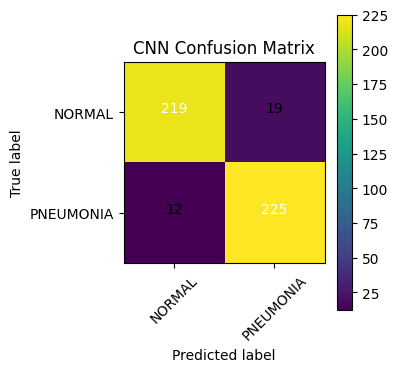

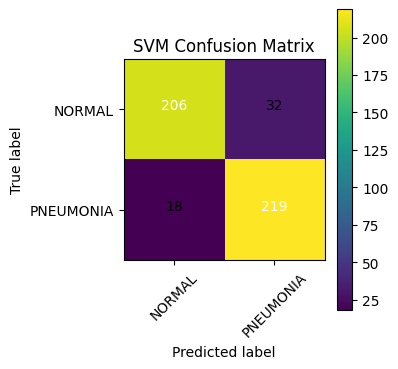

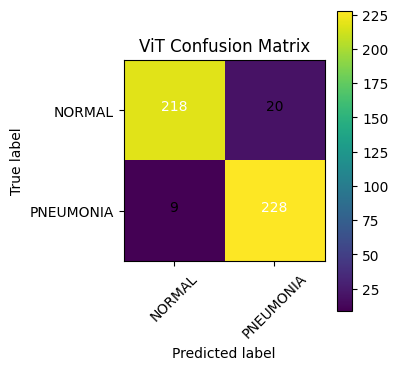

In [96]:
# CNN
plot_confusion_matrix(
    y_true, 
    y_pred, 
    class_names, 
    title="CNN Confusion Matrix"
)

# SVM
plot_confusion_matrix(
    y_test, 
    y_pred_svm, 
    class_names, 
    title="SVM Confusion Matrix"
)

# ViT
plot_confusion_matrix(
    y_true_vit, 
    y_pred_vit, 
    class_names, 
    title="ViT Confusion Matrix"
)


In [97]:
import matplotlib.pyplot as plt

def plot_vit_training(history_vit):
    epochs = range(1, len(history_vit["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # -------- Loss --------
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_vit["train_loss"], label="Train Loss")
    plt.plot(epochs, history_vit["val_loss"],   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ViT Loss Curve")
    plt.legend()

    # -------- Accuracy --------
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_vit["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history_vit["val_acc"],   label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ViT Accuracy Curve")
    plt.legend()

    plt.suptitle("ViT Training Curves")
    plt.tight_layout()
    plt.show()


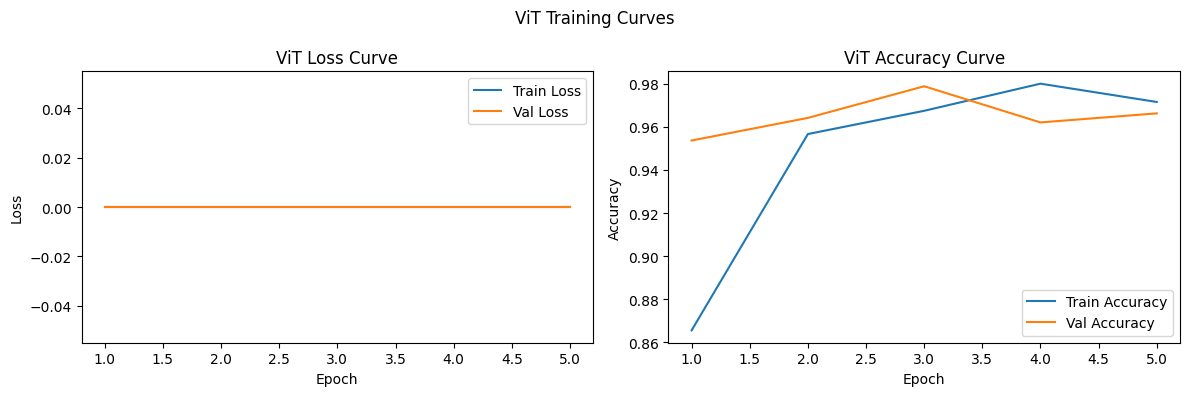

In [99]:
history_vit = {
    "train_loss": [0, 0, 0, 0, 0],
    "val_loss":   [0, 0, 0, 0, 0],

    "train_acc": [0.8655, 0.9567, 0.9675, 0.9801, 0.9716],
    "val_acc":   [0.9537, 0.9642, 0.9789, 0.9621, 0.9663]
}

plot_vit_training(history_vit)
